# 浊度时间序列折线图

读取 `data/merged.xlsx`，分别绘制 `FILT. NTU`、`NTU` 和 `R/W NTU` 的原始时间序列。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120

possible_paths = [Path("data/merged.xlsx"), Path("../data/merged.xlsx")]
DATA_PATH = next((path for path in possible_paths if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("找不到 data/merged.xlsx，请从项目根目录或 temp 目录运行 notebook。")

print(f"数据文件：{DATA_PATH.resolve()}")

数据文件：/Users/jinyu/workspace/2026亚太杯/data/merged.xlsx


In [2]:
df = pd.read_excel(DATA_PATH, sheet_name="Merged")

date_text = pd.to_datetime(df["DATE"], errors="coerce").dt.strftime("%Y-%m-%d")
time_text = df["TIME"].astype(str).str.strip()
df["DATETIME"] = pd.to_datetime(date_text + " " + time_text, errors="coerce")
turbidity_cols = ["FILT. NTU", "NTU", "R/W NTU"]
for col in turbidity_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

turbidity = (
    df[["DATETIME"] + turbidity_cols]
    .dropna(subset=["DATETIME"])
    .sort_values("DATETIME")
)

print(f"时间范围：{turbidity['DATETIME'].min()} 至 {turbidity['DATETIME'].max()}")
print(f"总记录数：{len(turbidity):,}")
for col in turbidity_cols:
    print(f"{col} 有效观测：{turbidity[col].notna().sum():,}，缺失：{turbidity[col].isna().sum():,}")

turbidity.head()

时间范围：2025-01-01 07:00:00 至 2026-04-01 05:00:00
总记录数：5,460
FILT. NTU 有效观测：5,460，缺失：0
NTU 有效观测：5,124，缺失：336
R/W NTU 有效观测：5,460，缺失：0


,DATETIME,FILT. NTU,NTU,R/W NTU
0,2025-01-01 07:00:00,0.04,0.12,150
1,2025-01-01 09:00:00,0.05,0.12,120
2,2025-01-01 11:00:00,0.05,0.12,82
3,2025-01-01 13:00:00,0.05,0.11,62
4,2025-01-01 15:00:00,0.05,0.11,56


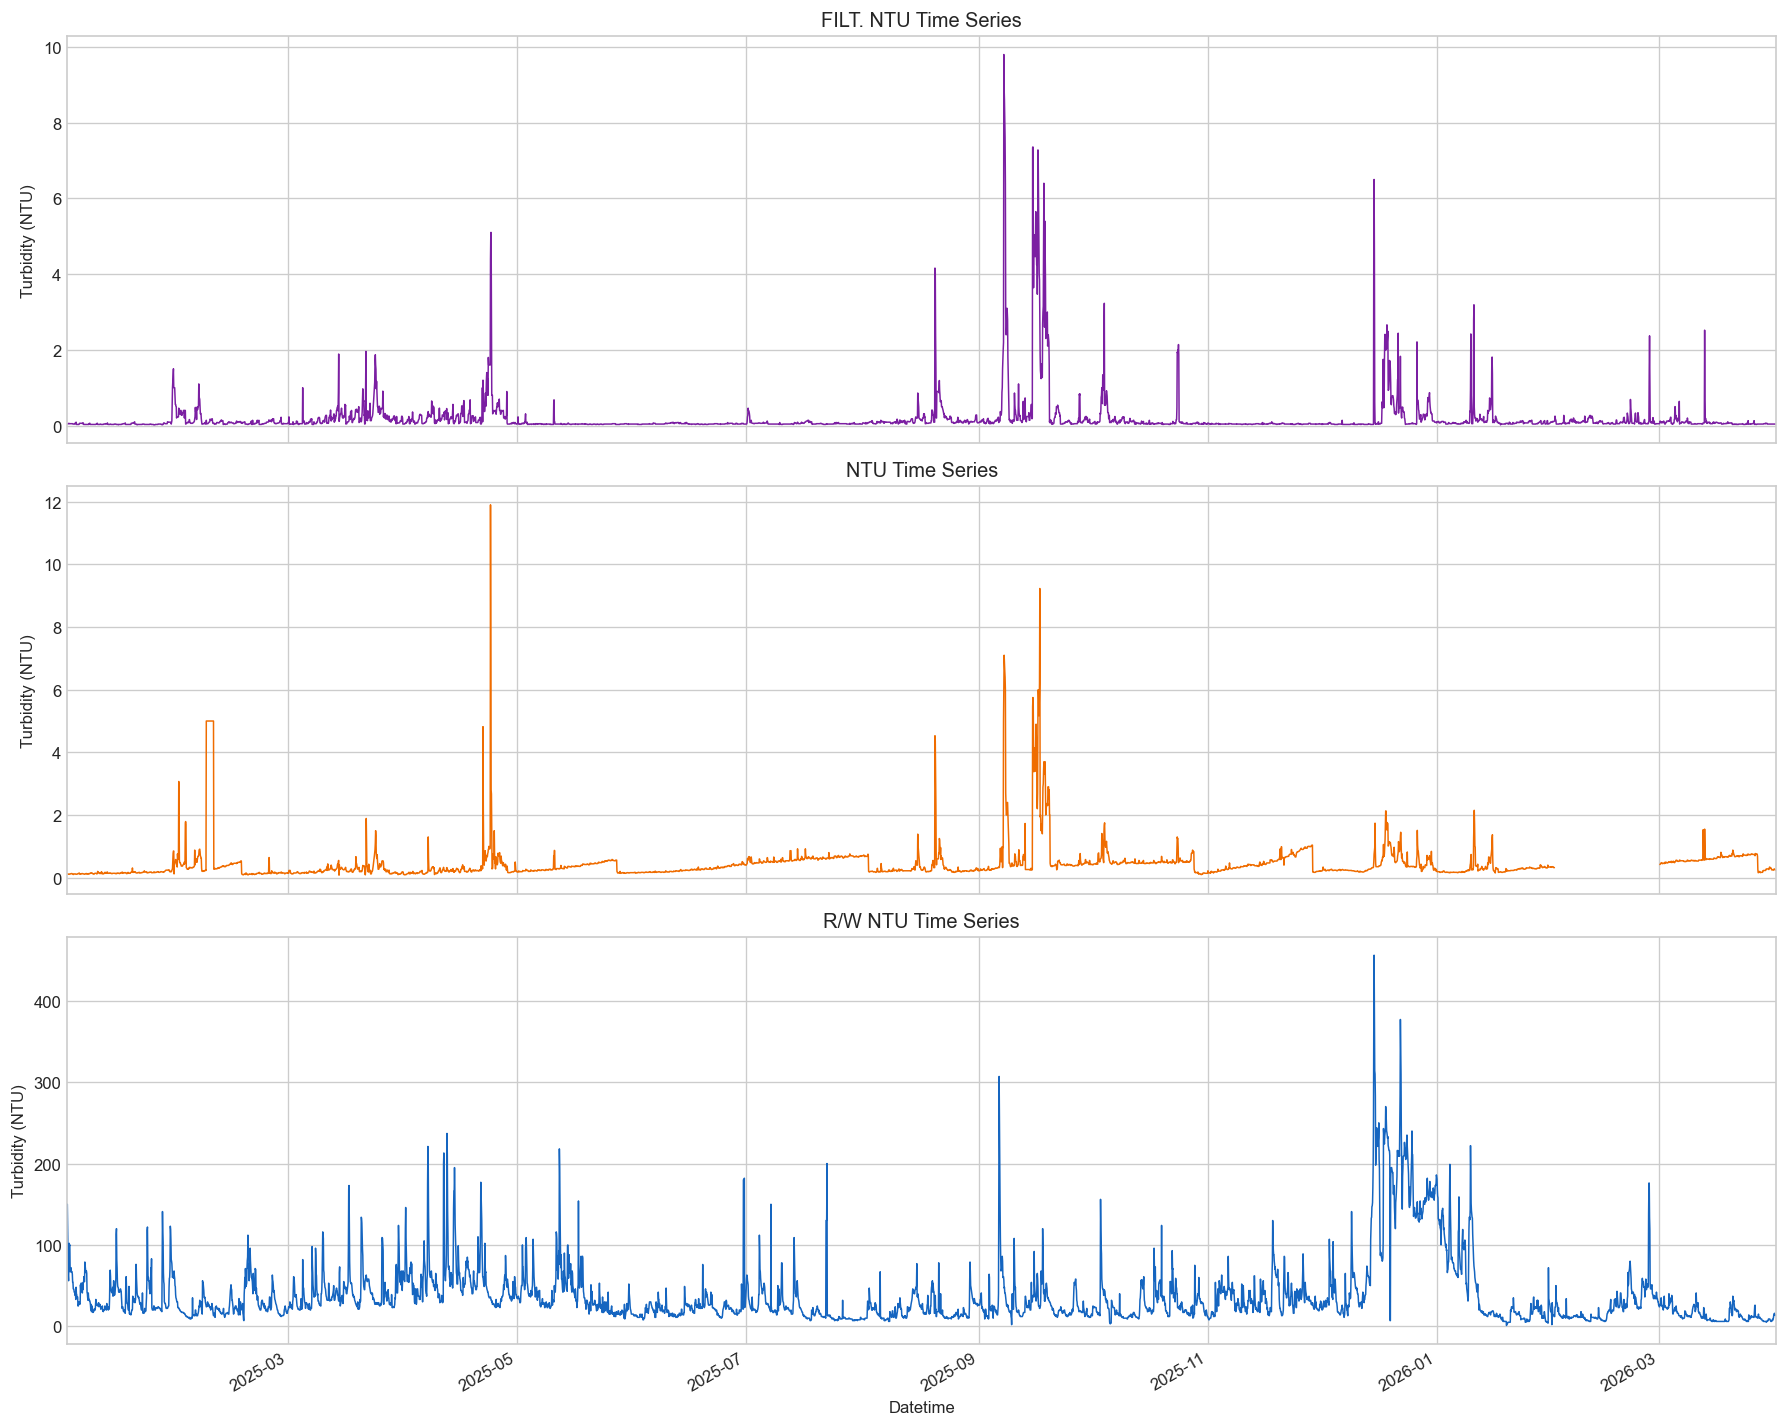

In [3]:
plot_settings = [
    ("FILT. NTU", "#7b1fa2"),
    ("NTU", "#ef6c00"),
    ("R/W NTU", "#1565c0"),
]

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

for ax, (col, color) in zip(axes, plot_settings):
    ax.plot(
        turbidity["DATETIME"],
        turbidity[col],
        color=color,
        linewidth=0.9,
    )
    ax.set_title(f"{col} Time Series")
    ax.set_ylabel("Turbidity (NTU)")
    ax.margins(x=0)

axes[-1].set_xlabel("Datetime")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## FILT. NTU 相邻时刻差分

计算每个时刻的 `FILT. NTU` 与前一时刻数值之差：

$$\Delta FILT.NTU_t = FILT.NTU_t - FILT.NTU_{t-1}$$

绘图时将差分值截断至 $[-1, 1]$。

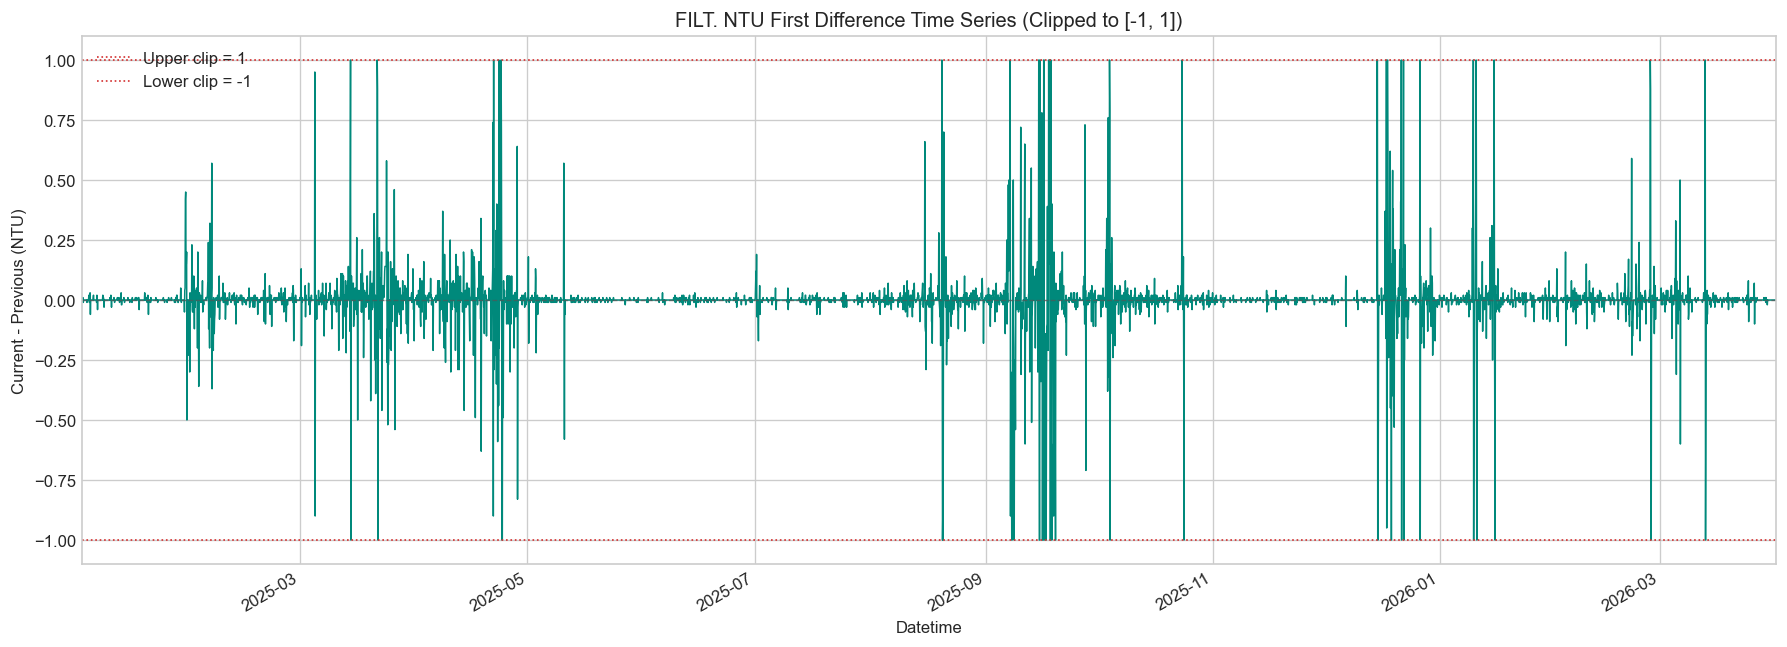

In [4]:
turbidity["FILT. NTU_diff"] = turbidity["FILT. NTU"].diff()
turbidity["FILT. NTU_diff_clipped"] = turbidity["FILT. NTU_diff"].clip(-1, 1)

fig, ax = plt.subplots(figsize=(15, 5.5))
ax.plot(
    turbidity["DATETIME"],
    turbidity["FILT. NTU_diff_clipped"],
    color="#00897b",
    linewidth=0.9,
)
ax.axhline(0, color="#555555", linestyle="--", linewidth=0.8, alpha=0.7)
ax.axhline(1, color="#d32f2f", linestyle=":", linewidth=1.0, label="Upper clip = 1")
ax.axhline(-1, color="#d32f2f", linestyle=":", linewidth=1.0, label="Lower clip = -1")

ax.set_title("FILT. NTU First Difference Time Series (Clipped to [-1, 1])")
ax.set_xlabel("Datetime")
ax.set_ylabel("Current - Previous (NTU)")
ax.set_ylim(-1.1, 1.1)
ax.legend()
ax.margins(x=0)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()